In [3]:
import h5py
import pandas as pd
import numpy as np
import sys
from types import SimpleNamespace
import matplotlib.pyplot as plt
from astropy import units as u
from flossy.flossy import flossyGUI
from PyQt5.QtWidgets import QApplication

tic = 177162802

In [ ]:
file_name = "/Users/michi/Documents/Git/SPB-astroseismology/results_spb1.hdf5"
itprw = h5py.File(file_name)
list(itprw.keys())

df = pd.DataFrame()


In [ ]:
pw_file = f'C:/Users/michi/Documents/Git/SPB-astroseismology/pw_tic{tic}.csv'
# Periodogram CSV file
pg_file = f'C:/Users/michi/Documents/Git/SPB-astroseismology/pg_tic{tic}.csv'
# Read the CSV files
pw = pd.read_csv(pw_file) 
pg = pd.read_csv(pg_file)
# Extract relevant columns from the CSV files
pw_periods = 1/pw.frequency.values
pw_e_periods = pw.e_frequency.values * pw_periods**2
pw_amplitudes = pw.amp.values
pg_periods = 1/pg.freq.values
pg_amplitudes = pg.amp.values
# Give astropy units to the just extracted columns 
pw_periods *= u.day
pw_e_periods *= u.day
pw_amplitudes = pw_amplitudes * 1e-3 * u.dimensionless_unscaled # ppt
pg_periods *= u.day
pg_amplitudes = pg_amplitudes * 1e-3 * u.dimensionless_unscaled # ppt
# Give a title to the figure
title = f'TIC {tic}'
data = SimpleNamespace(
    pw_periods=pw_periods,
    pw_e_periods=pw_e_periods,
    pw_amplitudes=pw_amplitudes,
    pg_periods=pg_periods,
    pg_amplitudes=pg_amplitudes,
    title=title
)

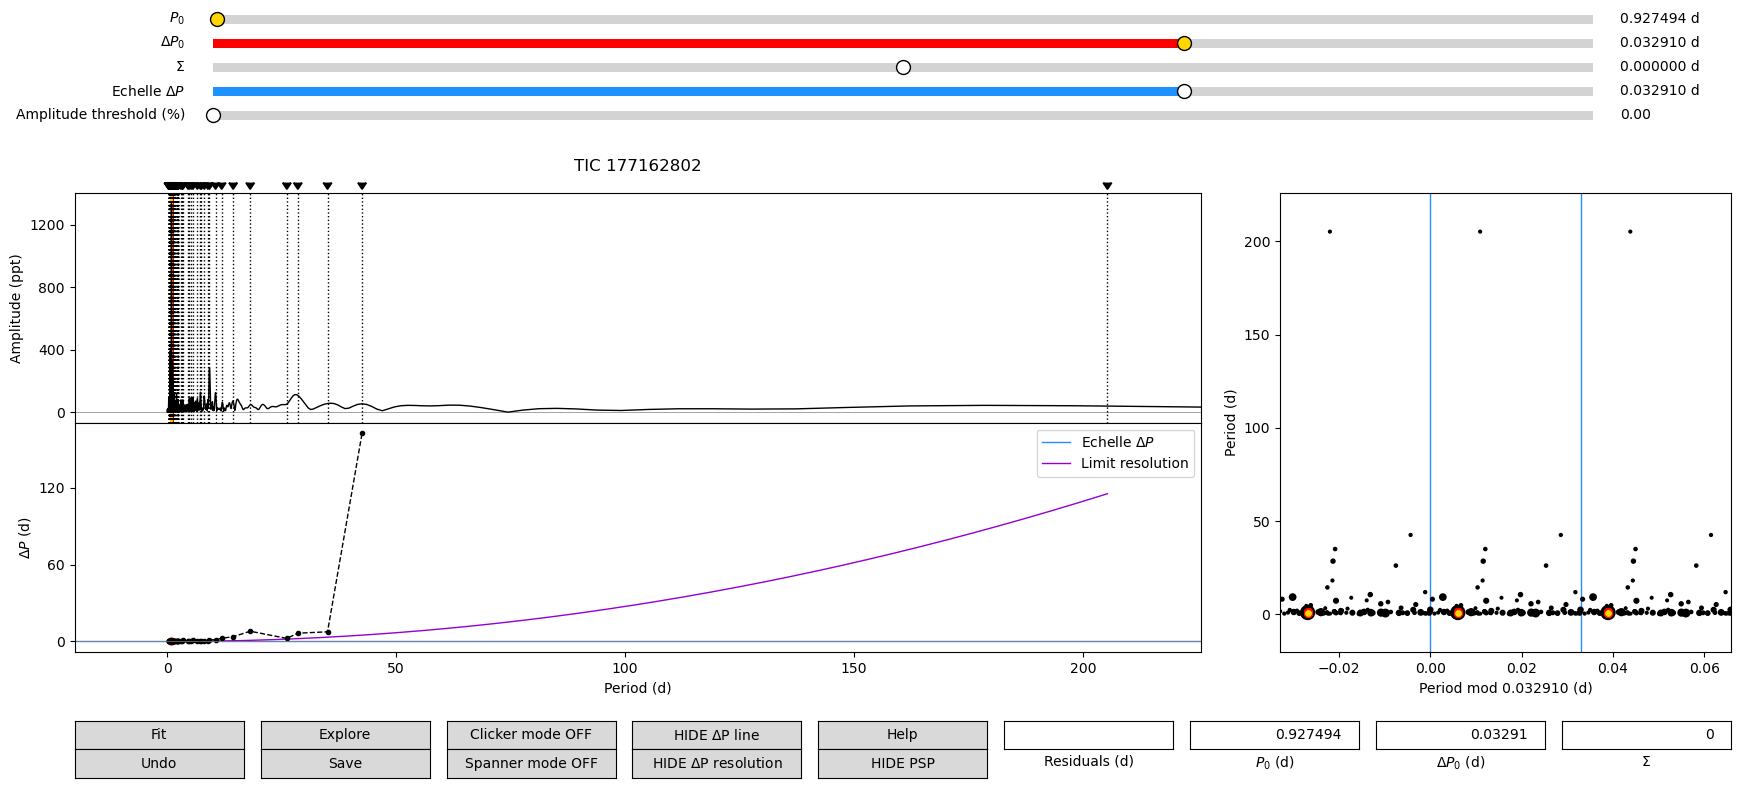

In [ ]:
GUI = flossyGUI(
        pw_periods=data.pw_periods,
        pw_e_periods=data.pw_e_periods,
        pw_amplitudes=data.pw_amplitudes,
        pg_periods=data.pg_periods,
        pg_amplitudes=data.pg_amplitudes,
        ID=data.title,
        freq_resolution=1/u.yr
    )
# Run the interface using a context manager
with GUI as flossy:
    app = QApplication([])
    plt.show()
    sys.exit(app.exec_())